# Running the HMA Synthesizer on 8 tables in a few minutes

# Overview

As an SDV Community user, you may have encountered limitations within the HMA Synthesizer when you've tried to use it for more than 3-5 tables at a relational depth greater than 3.

In this tutorial, we'll provide you with some guidance for how to overcome the scalability challenges of HMA by simplifying your schema. This way, you can maximize your use of HMA Synthesizer before considering an upgrade to [HSA Synthesizer](https://docs.sdv.dev/sdv/multi-table-data/modeling/synthesizers/hsasynthesizer).

> *<font color='blue'>Many of our community users have used HMA successfully and highlighted optimizations that worked for them. One team called out dropping “housekeeping columns,” and another team was able to  drop reference tables. We will continue to add tips like these into the tutorial as we find more patterns.</font>*

In [1]:
import warnings

warnings.filterwarnings("ignore")

# Testing a consumer banking application with synthetic data

For this tutorial, let's say we want to test a consumer banking application that allows customers to check their account balances, apply for loans, see a list of credit card transactions, and perform other common financial actions. We'll assume that the application utilizes a financial database which we will describe below. (As a note, this dataset was released in 1999 by a Czech bank for a data mining competition. Specifically, we'll use the [version hosted by Kaggle](https://www.kaggle.com/datasets/mariammariamr/1999-czech-financial-dataset/data).)

This datasets is available as a demo dataset in SDV. To load the datasets we can use the `download_demo` functionality and pass in `financial` as the name of the dataset. The function will retrieve the dataset and its associated metadata that has been validated.

In [2]:
from sdv.datasets.demo import download_demo

real_data, metadata = download_demo(modality="multi_table", dataset_name="financial")

real_data.keys()

dict_keys(['account', 'card', 'client', 'disp', 'district', 'loan', 'order', 'trans'])

# Understanding the data

This data has the eigth tables:

- **loan**: each row represents a bank loan, along with the account it's linked to
- **client**: each row represents a unique banking client
- **district**: each row represents the demographic characteristics of a specific Czech district
- **trans**: each row represents a financial transaction
- **account**: each row represents an account's static information
- **card**: each row represents an issued credit card, along with the account it is linked to
- **order**: each row represents the characteristics of a payment order
- **disp**: each row links together a client and an account

Here's a diagram that visualizes the relationships between these tables.

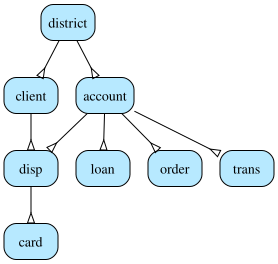

In [3]:
metadata.visualize(show_table_details=None, show_relationship_labels=False)

Because our application facilitates financial transactions on behalf of our customers, we want to generate a large volume of synthetic data that best mirrors the financial activity happening in the application. This includes loans, credit cards, transactions, accounts, and clients and the relationships between them.

The **district table** is an outlier because it represents district-level demographic information that is neither modified by the users of our application, nor representative of the financial transactions we want to emulate. This makes it a handy [reference table](https://en.wikipedia.org/wiki/Reference_table) that we want to preserve as-is, and therefore exclude from our synthetic data generation pipeline.

In [4]:
real_data["district"].head(3)

,district_id,A2,A3,A4,A5,A6,A7,A8,A9,A10,A11,A12,A13,A14,A15,A16
0,1,Hl.m. Praha,Prague,1204953,0,0,0,1,1,100.0,12541,0.2,0.43,167,85677.0,99107
1,2,Benesov,central Bohemia,88884,80,26,6,2,5,46.7,8507,1.6,1.85,132,2159.0,2674
2,3,Beroun,central Bohemia,75232,55,26,4,1,5,41.7,8980,1.9,2.21,111,2824.0,2813


> *<font color='blue'>If we look at the district table, it has information about the district itself, such as "No. of Inhabitants," "Unemployment rate in 1995," and "Unemployment rate in 1996." These variables do not change (or if they do, this table does not have that data). There are 77 districts. We do not intend to synthesize new districts, as it wouldn't make sense to do so.</font>*

## Simplifying the data

Let's drop the district table from our dictionary of DataFrame objects and update the metadata.

In [5]:
real_data.pop("district")
metadata.remove_table("district")

Now we need to update the columns' sdtypes that reference the `district` table. Initially they were foreign key references to the primary key of `district` table, now we want to consider them as categorical columns to perserve the correlation between columns.

We need to make this update to:
* `client` table
* `account` table

In [6]:
metadata.update_columns_metadata(
    table_name="client", column_metadata={"district_id": {"sdtype": "categorical"}}
)

metadata.update_columns_metadata(
    table_name="account", column_metadata={"district_id": {"sdtype": "categorical"}}
)

In [7]:
metadata.validate()
metadata.validate_data(real_data)

Now let's visualize our new metadata.

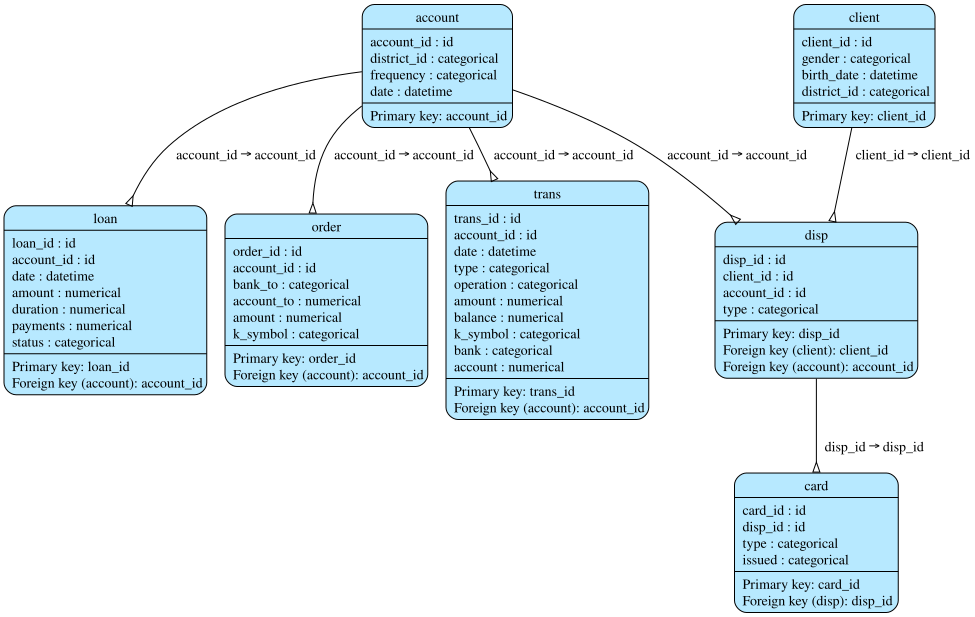

In [8]:
metadata.visualize()

We can see that the metadata has been updated to remove the reference to `district`.

# HMA Synthesizer

## Training the synthesizer

We're now ready to use HMA Synthesizer to train a model and generate synthetic data. We start by importing the HMA Synthesizer class, passing in our crafted metadata during instantiation, and then fitting the model.

In [9]:
from sdv.multi_table import HMASynthesizer

hma_synthesizer = HMASynthesizer(metadata, verbose=False)
hma_synthesizer.fit(real_data)

It takes approximately 23 minutes on a MacBook Pro (with the M3 Pro chip and 36 GB of RAM) for SDV to learn the patterns from our tables (which is a long time).

> *<font color='blue'>By simply removing the district table, we reduced the time it takes to fit HMA synthesizer to 23 minutes from several hours.</font>*

## Sampling from HMA

During the sampling phase, when the model generates synthetic data, we can choose the amount of data we want synthesized using the scale parameter. This parameter accepts a float value that corresponds to the volume of data we want synthesized:

- **0.2**: 20% of the size of the original data
- **1.0**: 100% of the size of the original data
- **2.0**: 200% of the size of the original data

Let's generate synthetic data at 20% of the original volume of data.


In [10]:
hma_synthetic_data = hma_synthesizer.sample(scale=0.2)

If we time it, we'll notice that the SDV took about 2 minutes to generate data at 20% scale. The higher the proportion, the longer HMA Synthesizer will take to synthesize the data. This makes HMA Synthesizer ideal for proof-of-concept projects for multi-table synthetic data, but not for large-scale production use.

|                   | 20% Scale                | 100% Scale               | 200% Scale                 |
|-------------------|--------------------------|--------------------------|----------------------------|
| HMA Sampling Time | 127 seconds (~2 minutes) | 900 seconds (15 minutes) | 2325 seconds (~39 minutes) |

To check the quality of the data, we will use `scale=1.0`.


In [11]:
hma_synthetic_data = hma_synthesizer.sample(scale=1.0)

## Evaluating the quality of the synthetic data

Next, we can evluate the quality of the synthetic data generated using HMA. Let's first run the [Diagnostic Report](https://docs.sdv.dev/sdv/multi-table-data/evaluation/diagnostic) to validate some basic checks.

In [12]:
from sdv.evaluation.multi_table import run_diagnostic

diagnostic_report = run_diagnostic(
    real_data=real_data,
    synthetic_data=hma_synthetic_data,
    metadata=metadata,
    verbose=False,
)

From this report, we can tell that HMA got the basics right.

| Diagnostic Report Components | Score |
|------------------------------|-------|
| Data Validity                | 100%  |
| Data Structure               | 100%  |
| Relationship Validity        | 100%  |
| Overall Score (Average)      | 100%  |

Next, let's understand the quality of this data at a deeper level using the [Quality Report](https://docs.sdv.dev/sdv/multi-table-data/evaluation/data-quality).

In [13]:
from sdv.evaluation.multi_table import evaluate_quality

diagnostic_report = evaluate_quality(
    real_data=real_data,
    synthetic_data=hma_synthetic_data,
    metadata=metadata,
    verbose=False,
)

| Quality Report Components | Score  |
|---------------------------|--------|
| Column Shapes             | 82.95% |
| Column Pair Trends        | 79.28% |
| Cardinality               | 98.47% |
| Intertable Trends         | 82.96% |
| Overall Score (Average)   | 85.91% |


An overall score of 85% is good, with the standout score being Cardinality, which describes the number of children each parent row has.

We've demonstrated how to improve the performance of the HMA Synthesizer by simplifying and cleaning the metadata. However, even with optimization, there is a limit to how much HMA can do within an acceptable time frame. This is why we developed the [HSA Synthesizer](https://docs.sdv.dev/sdv/multi-table-data/modeling/synthesizers/hsasynthesizer), available in SDV Enterprise.

# Conclusion

In this tutorial, we explored how to simplify a dataset schema to better prepare it for modeling by the HMA Synthesizer available in the SDV Community.

> *<font color='blue'>You know your database best. The best AI models are built through  collaboration between developers, software engineers and/or data scientists that know their data or business application, and products like SDV. Many of our users currently succeed by optimizing their schema, and our team wants you to succeed within the SDV Community. We hope that this tutorial has highlighted how you can bring your deep understanding of your data to succeed with HMA. We will continue to add more optimization tips to this and/or subsequent tutorials.</font>*


| Modification                                                                    | Effect                                                                                                                                                                                                                                         |
|---------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| Removed districts table, since synthesizing new districts does not make sense.  | This drastically changed the time it takes to model using HMA.                                                                                                                                                                                 |
| Updated the sdtype for district_id in different tables to categorical           | Since there were only 77 districts, this helps preserve correlation between districts and other variables in different tables. For example, if there is a correlation between people in a given district and the quantity of loans they took.  |


For more complex multi-table schemas with many rows of data, try **[HSA Synthesizer](https://docs.sdv.dev/sdv/multi-table-data/modeling/synthesizers/hsasynthesizer)**!